In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.table import Table

import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from matplotlib.colors import LogNorm

import torch
import pyStarlet_master_2D1D as pys


Numba imported


## TODOS

- #1 play around with binning
- initialization (with starlet transform? with kmeans? with GMM?)
- how do get the pytorch + starlet transformed
    - starlet as part of the loss function (L0 vs L1, read the IEEE version of the GMCA paper)
    - use starlet instead of the smoothness gradient
    - try contrastive / orthogonality between different sources (in the image space)

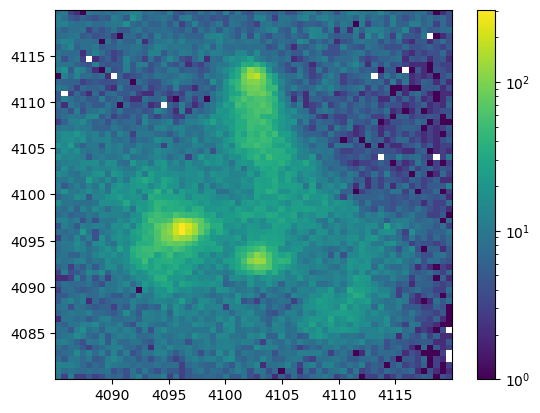

In [ ]:
## Load the data into a pandas DataFrame

EVT_FILE = 'acisi_merged.fits'
hdu = fits.open(EVT_FILE)
evt_data = hdu[1].data

cols = ['energy', 'x', 'y', 'ccd_id']
df = Table([evt_data[c] for c in cols], names=cols).to_pandas()

XMIN = 4085
XMAX = 4120
YMIN = 4080
YMAX = 4120

subset = df[(df['x'] > XMIN) & (df['x'] < XMAX) & \
            (df['y'] > YMIN) & (df['y'] < YMAX) & \
            (df['energy'] > 2000) & (df['energy'] < 5000)]

# bin x by a factor of 8, energy by a factor of 10
BINX = 8
BINY = 8
BINE = 10

_ = plt.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), cmap='viridis', norm=LogNorm())
plt.colorbar()

spectral_cube, _ = np.histogramdd(subset[['energy', 'x', 'y']].values, bins=(BINE, BINX, BINY))


In [ ]:

nouveau_i=spectral_cube #[i1:i2]
cube_i = pys.Starlet_Forward3D(nouveau_i,J=3)

In [4]:
from GMCA import GMCA

In [ ]:

nb_sources = 3
(Sources_j,g_A_j)=GMCA(cube_i,nouveau_i,nb_sources,0,JMAX=2,rL1=0,UseP=1,Init=0,nmax=5000,SPC=0,verb=1,mints=2.5) # you can play with the parameters


Initializing ...
Starting main loop ...
 
  - Final k:  2.5
  - Maximum number of iterations:  5000
  - Using support-based threshold estimation
  - Using L0 norm rather than L1
  - AMCA rather than GMCA
 
 ... processing ...
Stopped after 5000 iterations, in 32.0 seconds


In [14]:
# Turning GMCA output into images and spectra
def reconstitute_source(im,spec):
    #print("\t shape of im and spec are", im.shape, " and ", spec.shape)
    Cube_source=im[:,:,None] * spec[None, None, :]
    #print("\t after recasting, the shapes are", im[:,:,None].shape, " and ", spec[None, None, :].shape)
    #print("\t Cube source shape is", Cube_source.shape)
    return Cube_source

def reconstruct_comp(Sources, g_A):
    """
    Reconstruct cubes for each component from GMCA outputs.

    
    Parameters:
    - Sources (ndarray): Array of shape (N, M, M) representing the sources.
    - g_A (ndarray): Array of shape (M, N) representing the mixing matrix.

    Returns:
    - spectrum (ndarray): Array of shape (N, M) representing the reconstructed spectra for each component.
    - image_source (ndarray): Array of shape (N, M, M) representing the reconstructed image cubes for each component.
    """
    spectrum = np.zeros(shape=(Sources[:, 0, 0].shape[0], g_A[:, 0].shape[0]))
    image_source = np.zeros(Sources.shape)
    # make an empty cube with the same shape as sources
    
    for i, source in enumerate(Sources):
        print("i = %.0i" % i)
    #     print(np.all(source == Sources[i]))
        spectrum[i, :] = np.sum(reconstitute_source(source, g_A[:, i]), axis=(0, 1))
        print("\t sum of g_A[:,i] is", sum(g_A[:,i]))
        # here, source is the same as Sources[i]
        image_source[i, :, :] = np.sum(reconstitute_source(Sources[i], g_A[:, i]), axis=(2))

    return spectrum, image_source


## print("sum is", np.sum(g_A_j))
spectrum, image_source = reconstruct_comp(Sources_j,g_A_j)
print("In the end, spectrum shape is", spectrum.shape)
print("In the end, image array shape is", image_source.shape)

i = 0
	 sum of g_A[:,i] is -8.987273013333683
i = 1
	 sum of g_A[:,i] is -0.062298892810006466
i = 2
	 sum of g_A[:,i] is 1.0091688101529988
i = 3
	 sum of g_A[:,i] is -0.05723397046529482
In the end, spectrum shape is (4, 100)
In the end, image array shape is (4, 64, 64)


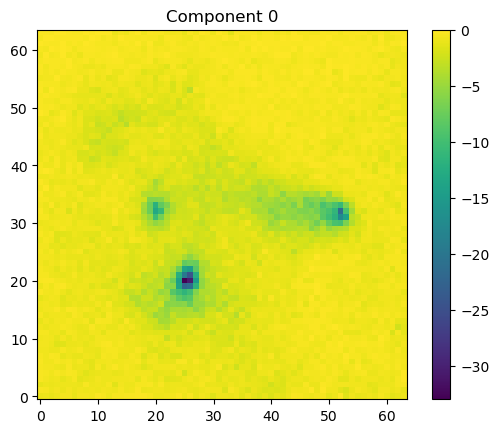

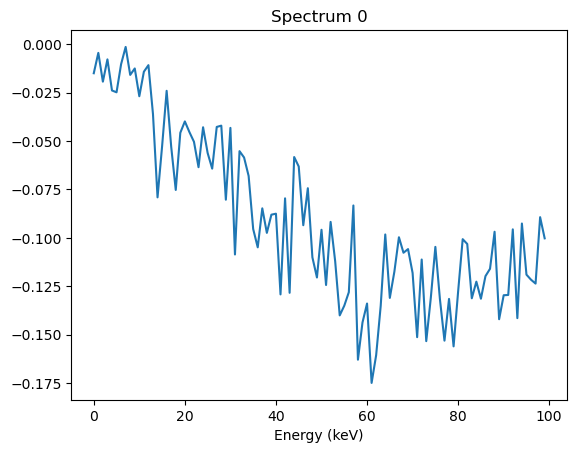

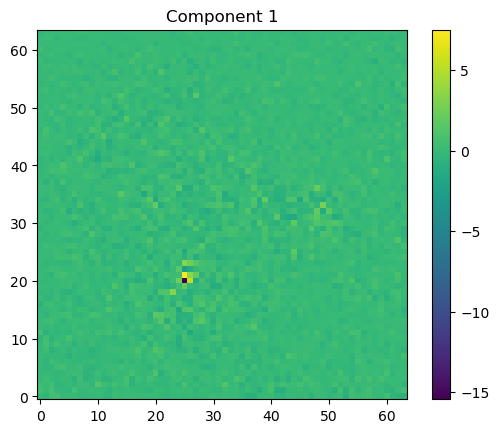

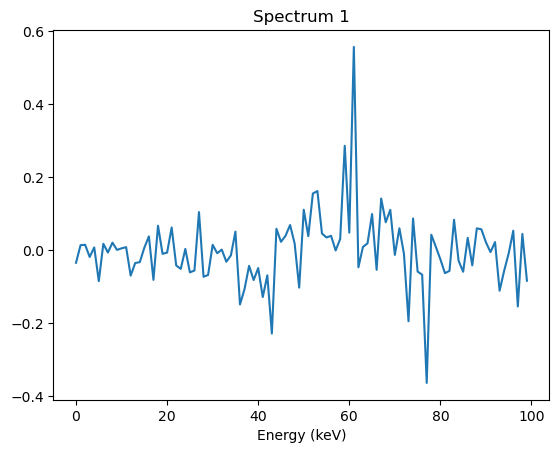

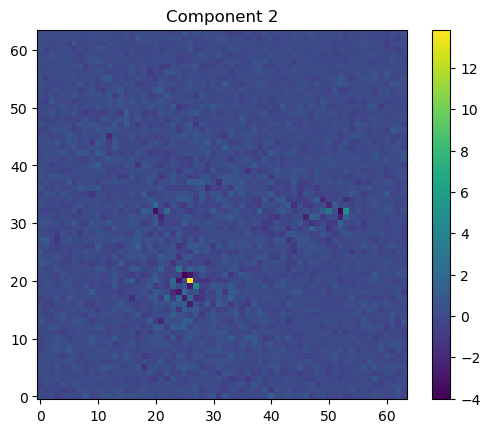

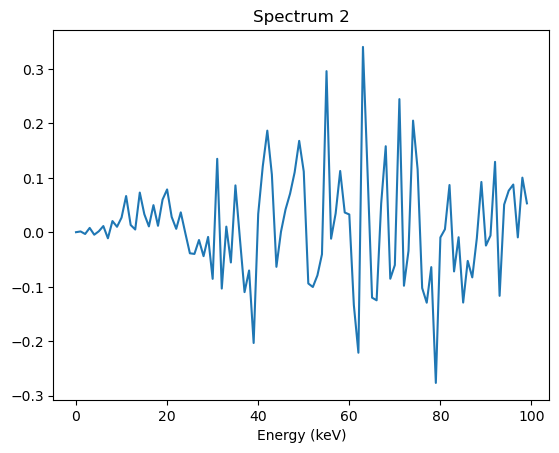

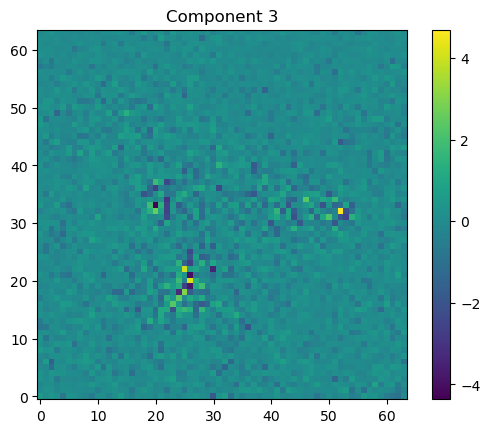

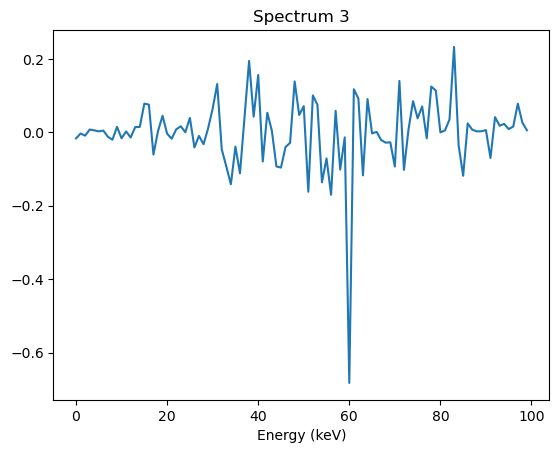

In [15]:
for i in range(nb_sources):
    plt.figure()
    plt.imshow(Sources_j[i], origin="lower")

    plt.colorbar()
    plt.title(f'Component {i}')
    plt.show()

    plt.figure()
    # plot e_centers as well here
    plt.plot(g_A_j[:, i])
    plt.xlabel('Energy (keV)')
    plt.title(f'Spectrum {i}')
    plt.show()